In [1]:
import pandas as pd
import requests
import json
import sqlite3
import numpy as np
import time
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import re as re
import seaborn as sns
from ast import literal_eval
import os
import geopandas as gpd
import folium
import mapclassify
import geodatasets
import leafmap


In [2]:
car_sales = pd.read_csv(r'../../data/Car_Sales-car_data.csv')

In [3]:
car_sales

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23901,C_CND_023902,12/31/2023,Martin,Male,13500,C & M Motors Inc,Plymouth,Voyager,Overhead Camshaft,Manual,Red,12000,60504-7114,Passenger,8583598,Pasco
23902,C_CND_023903,12/31/2023,Jimmy,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,DoubleÂ Overhead Camshaft,Auto,Black,16000,06457-3834,Hardtop,7914229,Middletown
23903,C_CND_023904,12/31/2023,Emma,Male,705000,Chrysler of Tri-Cities,BMW,328i,Overhead Camshaft,Manual,Red,21000,99301-3882,Sedan,7659127,Scottsdale
23904,C_CND_023905,12/31/2023,Victoire,Male,13500,Chrysler Plymouth,Chevrolet,Metro,DoubleÂ Overhead Camshaft,Auto,Black,31000,53546-9427,Passenger,6030764,Austin


In [4]:
car_sales.columns = car_sales.columns.str.replace('_'," ")

In [5]:
car_sales

,Car id,Date,Customer Name,Gender,Annual Income,Dealer Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer No,Body Style,Phone,Dealer Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23901,C_CND_023902,12/31/2023,Martin,Male,13500,C & M Motors Inc,Plymouth,Voyager,Overhead Camshaft,Manual,Red,12000,60504-7114,Passenger,8583598,Pasco
23902,C_CND_023903,12/31/2023,Jimmy,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,DoubleÂ Overhead Camshaft,Auto,Black,16000,06457-3834,Hardtop,7914229,Middletown
23903,C_CND_023904,12/31/2023,Emma,Male,705000,Chrysler of Tri-Cities,BMW,328i,Overhead Camshaft,Manual,Red,21000,99301-3882,Sedan,7659127,Scottsdale
23904,C_CND_023905,12/31/2023,Victoire,Male,13500,Chrysler Plymouth,Chevrolet,Metro,DoubleÂ Overhead Camshaft,Auto,Black,31000,53546-9427,Passenger,6030764,Austin


In [6]:
car_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer No      23906 non-null  object
 13  Body Style     23906 non-null  object
 14  Phone          23906 non-null  int64 
 15  Dealer Region  23906 non-null  object
dtypes: int64(3), object(13)
memory usage: 2.9+ MB


In [7]:
car_sales.isnull().sum()

Car id           0
Date             0
Customer Name    1
Gender           0
Annual Income    0
Dealer Name      0
Company          0
Model            0
Engine           0
Transmission     0
Color            0
Price ($)        0
Dealer No        0
Body Style       0
Phone            0
Dealer Region    0
dtype: int64

In [8]:
car_sales['Customer Name'] = car_sales['Customer Name'].fillna('John Doe')

In [9]:
car_sales

,Car id,Date,Customer Name,Gender,Annual Income,Dealer Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer No,Body Style,Phone,Dealer Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23901,C_CND_023902,12/31/2023,Martin,Male,13500,C & M Motors Inc,Plymouth,Voyager,Overhead Camshaft,Manual,Red,12000,60504-7114,Passenger,8583598,Pasco
23902,C_CND_023903,12/31/2023,Jimmy,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,DoubleÂ Overhead Camshaft,Auto,Black,16000,06457-3834,Hardtop,7914229,Middletown
23903,C_CND_023904,12/31/2023,Emma,Male,705000,Chrysler of Tri-Cities,BMW,328i,Overhead Camshaft,Manual,Red,21000,99301-3882,Sedan,7659127,Scottsdale
23904,C_CND_023905,12/31/2023,Victoire,Male,13500,Chrysler Plymouth,Chevrolet,Metro,DoubleÂ Overhead Camshaft,Auto,Black,31000,53546-9427,Passenger,6030764,Austin


In [10]:
columns_to_drop = ['Car id','Date','Customer Name','Phone']
car_sales = car_sales.drop(columns=columns_to_drop)
car_sales

,Gender,Annual Income,Dealer Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer No,Body Style,Dealer Region
0,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,Middletown
1,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,Aurora
2,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,Greenville
3,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,Pasco
4,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,Janesville
...,...,...,...,...,...,...,...,...,...,...,...,...
23901,Male,13500,C & M Motors Inc,Plymouth,Voyager,Overhead Camshaft,Manual,Red,12000,60504-7114,Passenger,Pasco
23902,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,DoubleÂ Overhead Camshaft,Auto,Black,16000,06457-3834,Hardtop,Middletown
23903,Male,705000,Chrysler of Tri-Cities,BMW,328i,Overhead Camshaft,Manual,Red,21000,99301-3882,Sedan,Scottsdale
23904,Male,13500,Chrysler Plymouth,Chevrolet,Metro,DoubleÂ Overhead Camshaft,Auto,Black,31000,53546-9427,Passenger,Austin


In [11]:
car_sales.isnull().sum()

Gender           0
Annual Income    0
Dealer Name      0
Company          0
Model            0
Engine           0
Transmission     0
Color            0
Price ($)        0
Dealer No        0
Body Style       0
Dealer Region    0
dtype: int64

In [12]:
car_sales_body_count = car_sales['Body Style'].value_counts()
car_sales_body_count

Body Style
SUV          6374
Hatchback    6128
Sedan        4488
Passenger    3945
Hardtop      2971
Name: count, dtype: int64

In [13]:
car_sales_test = car_sales.groupby('Body Style')['Company'].value_counts()

In [14]:
car_sales_test

Body Style  Company   
Hardtop     Chevrolet     406
            Dodge         333
            Mitsubishi    256
            Mercedes-B    183
            Ford          170
                         ... 
Sedan       Nissan        110
            Jeep           74
            Toyota         73
            Hyundai        65
            Buick          41
Name: count, Length: 126, dtype: int64

In [15]:
pivot_maker_style = car_sales.pivot_table(index='Company',columns='Body Style', aggfunc='size',fill_value=0)
pivot_maker_style

Body Style,Hardtop,Hatchback,Passenger,SUV,Sedan
Company,,,,,
Acura,0,269,48,372,0
Audi,70,13,37,348,0
BMW,0,260,0,324,206
Buick,20,212,152,14,41
Cadillac,45,102,232,110,163
Chevrolet,406,318,420,565,110
Chrysler,144,362,37,314,263
Dodge,333,345,216,633,144
Ford,170,434,336,440,234


Text(0, 0.5, 'Maker Name')

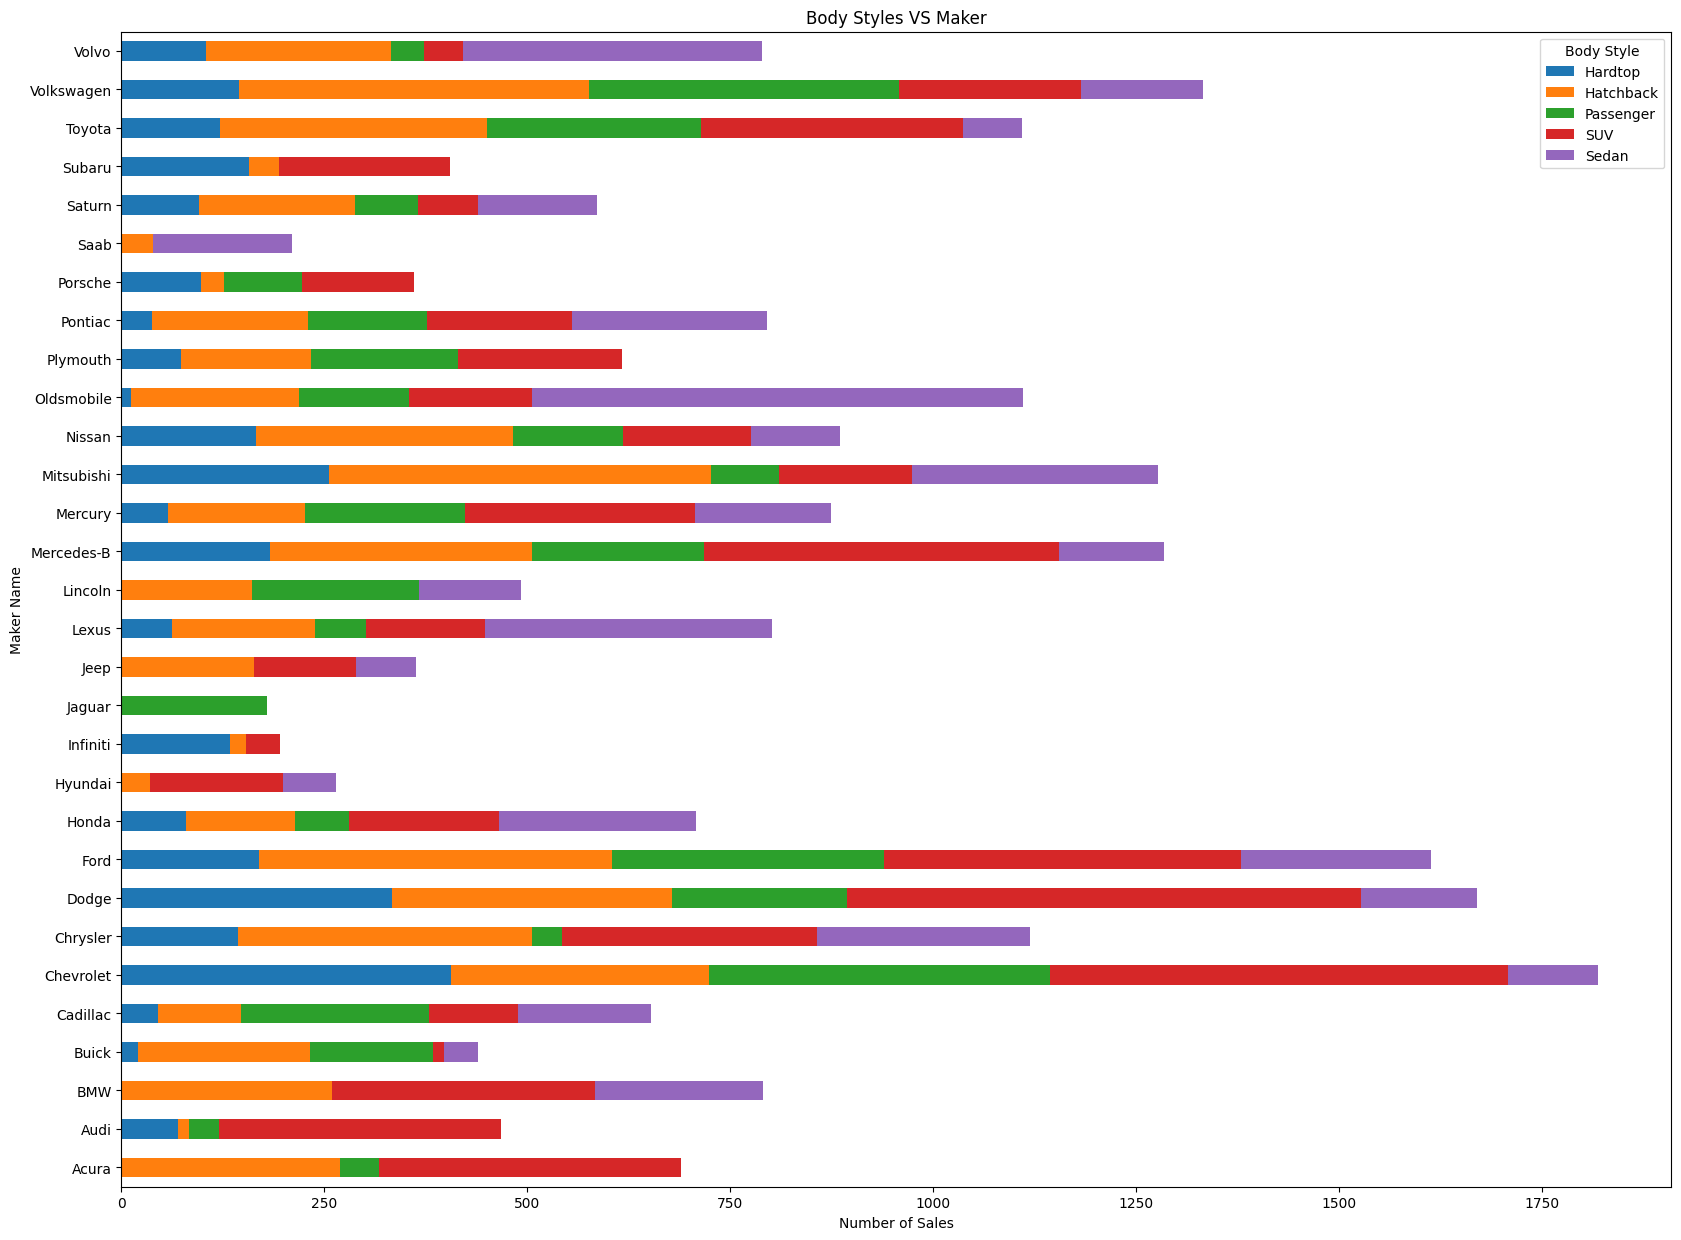

In [16]:
pivot_maker_style.plot(kind='barh',stacked=True, figsize=(20,15))
plt.title('Body Styles VS Maker')
plt.xlabel('Number of Sales')
plt.ylabel('Maker Name')

<Axes: xlabel='Body Style'>

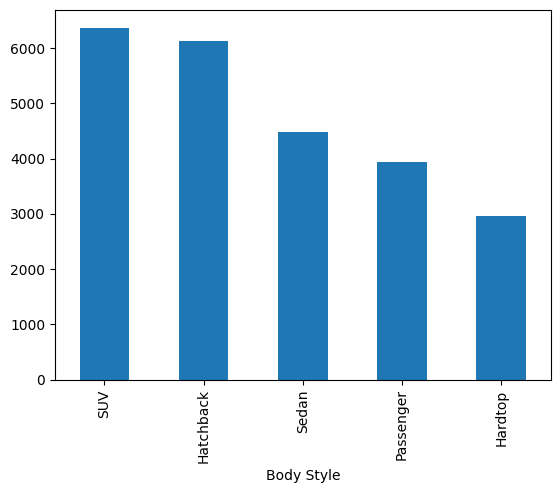

In [17]:
car_sales_body_count.plot(kind='bar')

Text(0, 0.5, 'Maker Name')

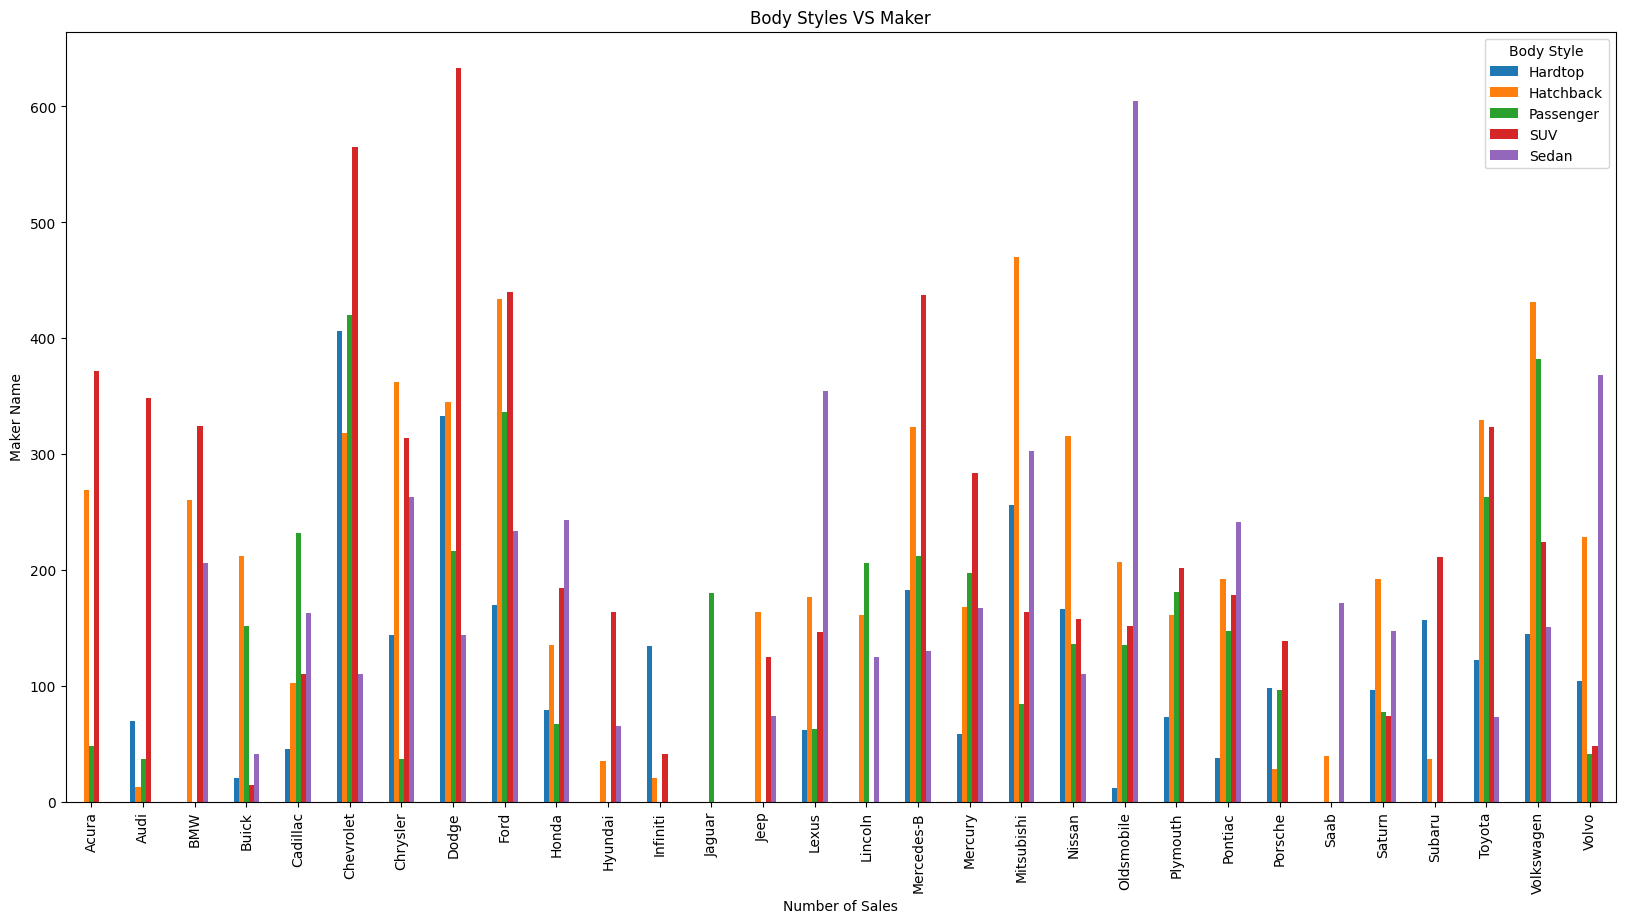

In [18]:
pivot_maker_style.plot(kind='bar',stacked=False, figsize=(20,10))
plt.title('Body Styles VS Maker')
plt.xlabel('Number of Sales')
plt.ylabel('Maker Name')

In [19]:
BS_Chev = pivot_maker_style.loc['Chevrolet']

<Axes: xlabel='Body Style'>

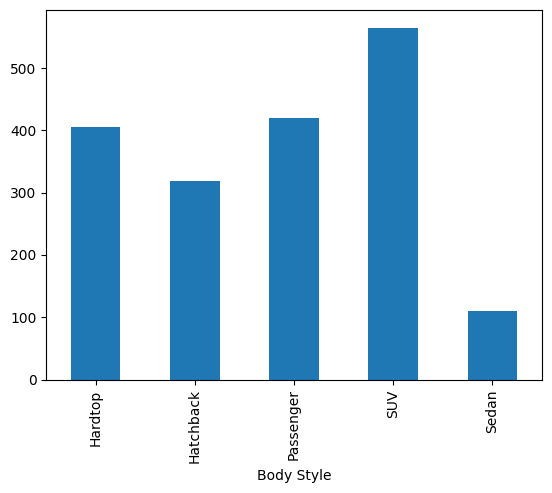

In [20]:
BS_Chev.plot(kind='bar')

In [21]:
car_sales_transmission = car_sales['Transmission'].value_counts()

In [22]:
car_sales_transmission

Transmission
Auto      12571
Manual    11335
Name: count, dtype: int64

In [23]:
car_sales_region = car_sales['Dealer Region'].value_counts()

In [24]:
car_sales_region

Dealer Region
Austin        4135
Janesville    3821
Scottsdale    3433
Pasco         3131
Aurora        3130
Greenville    3128
Middletown    3128
Name: count, dtype: int64

In [25]:
car_sales['Dealer Region'].unique().tolist()

['Middletown',
 'Aurora',
 'Greenville',
 'Pasco',
 'Janesville',
 'Scottsdale',
 'Austin']

In [26]:
city_state_map = {'Middletown' : 'Connecticut',
 'Aurora' : 'Colorado',
 'Greenville' : 'South Carolina',
 'Pasco' : 'Washington',
 'Janesville' : 'Wisconsin',
 'Scottsdale' : 'Arizona',
 'Austin' : 'Texas'}

car_sales['State'] = car_sales['Dealer Region'].map(city_state_map)
car_sales

,Gender,Annual Income,Dealer Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer No,Body Style,Dealer Region,State
0,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,Middletown,Connecticut
1,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,Aurora,Colorado
2,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,Greenville,South Carolina
3,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,Pasco,Washington
4,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,Janesville,Wisconsin
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23901,Male,13500,C & M Motors Inc,Plymouth,Voyager,Overhead Camshaft,Manual,Red,12000,60504-7114,Passenger,Pasco,Washington
23902,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,DoubleÂ Overhead Camshaft,Auto,Black,16000,06457-3834,Hardtop,Middletown,Connecticut
23903,Male,705000,Chrysler of Tri-Cities,BMW,328i,Overhead Camshaft,Manual,Red,21000,99301-3882,Sedan,Scottsdale,Arizona
23904,Male,13500,Chrysler Plymouth,Chevrolet,Metro,DoubleÂ Overhead Camshaft,Auto,Black,31000,53546-9427,Passenger,Austin,Texas


<Axes: xlabel='Dealer Region'>

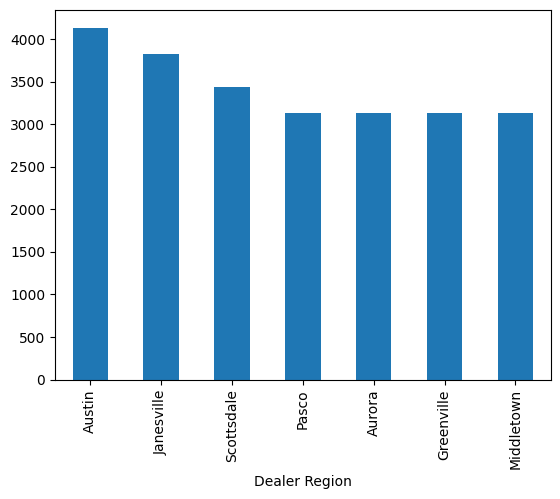

In [27]:
car_sales_region.plot(kind ='bar')

In [28]:
car_sales_state = car_sales.groupby('State')['Dealer Region'].value_counts().reset_index(name='Total Sales')
car_sales_state

,State,Dealer Region,Total Sales
0,Arizona,Scottsdale,3433
1,Colorado,Aurora,3130
2,Connecticut,Middletown,3128
3,South Carolina,Greenville,3128
4,Texas,Austin,4135
5,Washington,Pasco,3131
6,Wisconsin,Janesville,3821


<Axes: >

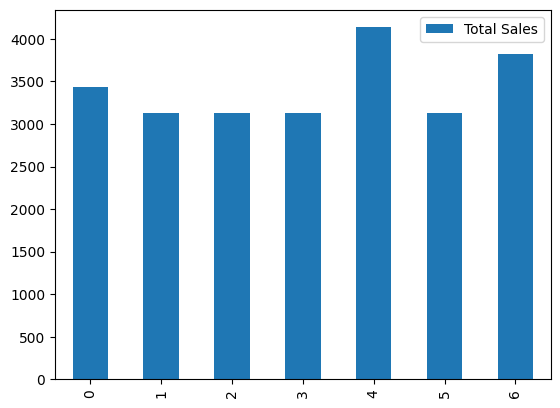

In [29]:
car_sales_state.plot(kind= 'bar')

In [36]:
m = leafmap.Map(center=[43,-75], zoom=2)